# Classification of Ice and Open Water of Yukon River using Sentinel-1 IW Product

This notebook classifies ice and open water in the Yukon River using Sentinel-1 SAR imagery from September 2022 to May 2023. The code from this notebook was adapted from code samples found on Copernicus's Data Space Ecosystem Documentation page: https://documentation.dataspace.copernicus.eu/notebook-samples/sentinelhub/ice_monitoring.html

The Tanana River Confluence connects the Yukon River to the Tanana River, which is a major shipping artery. Nenana, located on the Tanana River, is a central hub for Ruby Marine that transports heavy goods, oil, and vehicles for inland communities.

## Imports

In [69]:
import datetime
import getpass

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import geopandas as gpd
import json
from ipyleaflet import Map, GeoJSON, basemaps

from sentinelhub import (
    SHConfig,
    Geometry,
    DataCollection,
    MimeType,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
    SentinelHubCatalog, BBox, CRS,
)

## Credentials

In [70]:
# Input Sentinel Hub credentials
config = SHConfig()
config.sh_client_id = "sh-03b97588-8780-4ec9-b187-9f18c5aa9b8e"
config.sh_client_secret = "yr1wbYiDybefN5L6utkT2KzwDPhq48rW"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

## Defining the Bounds

In [90]:
# Load the river geometry from the GeoJSON file
SHAPE_PATH = "../data/raw/yukon_river_aoi.geojson"
river_gdf = gpd.read_file(SHAPE_PATH)

# Reproject temporarily just for metric resolution calculation
river_gdf_metric = river_gdf.to_crs("EPSG:32606")  # UTM zone 3N, meters-based
resolution = 40
print("Bounds:", river_gdf_metric.total_bounds)

# Keep river geometry in WGS84 for Sentinel Hub requests and visualization
river_gdf = river_gdf.to_crs("EPSG:4326")


# Load the GeoJSON data for visualization
data_geojson = json.load(open(SHAPE_PATH, "r"))

# Set center and zoom level
center = [65.15, -151.90]
zoom = 9

# Build and display interactive map
m = Map(basemap=basemaps.CartoDB.Voyager, center=center, zoom=zoom)
geo_json = GeoJSON(data=data_geojson)
m.add_layer(geo_json)
m

Bounds: [ 248030.83384819 7221440.68858142  289289.68615786 7246928.86433732]


Map(center=[65.15, -151.9], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

## Check Sentinel Hub for available imagery

In [72]:
# Query Sentinel Hub Catalog for Sentinel-1 IW data intersecting the river geometry
catalog = SentinelHubCatalog(config=config)

bbox = BBox(tuple(river_gdf.total_bounds), crs=CRS.WGS84)

results = list(catalog.search(
    DataCollection.SENTINEL1_IW.define_from("s1iw", service_url=config.sh_base_url),
    bbox=bbox,
    time=("2022-09-01", "2023-05-31"),
    fields={"include": ["id", "properties.datetime", "properties.orbitDirection"], "exclude": []}
))

print(f"Total scenes found: {len(results)}")
for r in results[:10]:
    print(r['id'], r['properties']['datetime'], r['properties'].get('orbitDirection', 'N/A'))

Total scenes found: 80
S1A_IW_GRDH_1SDV_20230430T162854_20230430T162919_048328_05CFF8_97FE_COG.SAFE 2023-04-30T16:28:54Z N/A
S1A_IW_GRDH_1SDV_20230430T162829_20230430T162854_048328_05CFF8_F734_COG.SAFE 2023-04-30T16:28:29Z N/A
S1A_IW_GRDH_1SDV_20230428T164516_20230428T164541_048299_05CEFC_BFBE_COG.SAFE 2023-04-28T16:45:16Z N/A
S1A_IW_GRDH_1SDV_20230428T164451_20230428T164516_048299_05CEFC_44BA_COG.SAFE 2023-04-28T16:44:51Z N/A
S1A_IW_GRDH_1SDV_20230418T162853_20230418T162918_048153_05CA1A_0EDB_COG.SAFE 2023-04-18T16:28:53Z N/A
S1A_IW_GRDH_1SDV_20230418T162828_20230418T162853_048153_05CA1A_05D9_COG.SAFE 2023-04-18T16:28:28Z N/A
S1A_IW_GRDH_1SDV_20230416T164515_20230416T164540_048124_05C921_9F50_COG.SAFE 2023-04-16T16:45:15Z N/A
S1A_IW_GRDH_1SDV_20230416T164450_20230416T164515_048124_05C921_81CF_COG.SAFE 2023-04-16T16:44:50Z N/A
S1A_IW_GRDH_1SDV_20230406T162853_20230406T162918_047978_05C42D_2C83_COG.SAFE 2023-04-06T16:28:53Z N/A
S1A_IW_GRDH_1SDV_20230406T162828_20230406T162853_047978_05C

## Define Time Slots

In [73]:
# Split the September 2022 – April 2023 period into 16 bi-monthly slots to capture freeze-thaw dynamics.
start = datetime.datetime(2022, 9, 1)
end = datetime.datetime(2023, 5, 31)
n_chunks = 19
tdelta = (end - start) / n_chunks
edges = [(start + i * tdelta).date().isoformat() for i in range(n_chunks)]
slots = [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

print("Monthly time windows:\n")
for slot in slots:
    print(slot)

Monthly time windows:

('2022-09-01', '2022-09-15')
('2022-09-15', '2022-09-29')
('2022-09-29', '2022-10-13')
('2022-10-13', '2022-10-28')
('2022-10-28', '2022-11-11')
('2022-11-11', '2022-11-25')
('2022-11-25', '2022-12-10')
('2022-12-10', '2022-12-24')
('2022-12-24', '2023-01-07')
('2023-01-07', '2023-01-22')
('2023-01-22', '2023-02-05')
('2023-02-05', '2023-02-19')
('2023-02-19', '2023-03-06')
('2023-03-06', '2023-03-20')
('2023-03-20', '2023-04-03')
('2023-04-03', '2023-04-18')
('2023-04-18', '2023-05-02')
('2023-05-02', '2023-05-16')


## Requesting Sentinel-1 (SAR) Data

The evalscript below:
- Inputs the VV band and dataMask
- Converts linear backscatter to decibels (dB), scaled to [0, 1]
- Outputs FLOAT32 values for further analysis

Pre-processing applied:
- **Radiometric calibration**: `SIGMA0_ELLIPSOID`
- **Speckle filter**: LEE 3×3
- **Geometric correction**: COPERNICUS DEM
- **Resolution**: HIGH (40 m × 40 m), ascending orbit

In [74]:
evalscript_sar = """
  function setup() {
    return {
      input: ["VV", "dataMask"],
      output: { bands: 2, sampleType: "FLOAT32"}
    }
  }

// visualizes decibels from -20 to +10
function toDb(linear) {
  var log = 10 * Math.log(linear) / Math.LN10
  return Math.max(0, (log + 20) / 30)
}

function evaluatePixel(sample) {
  var VV = sample.VV;
  return [toDb(VV), sample.dataMask];
}
"""


def get_sar_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_sar,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
                other_args={
                    "dataFilter": {
                        "resolution": "HIGH",
                        "mosaickingOrder": "mostRecent",
                    },
                    "processing": {
                        "backCoeff": "SIGMA0_ELLIPSOID",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 3,
                            "windowSizeY": 3,
                        },
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(river_gdf_metric.geometry.values[0], crs=river_gdf_metric.crs),
        resolution=[40, 40],
        config=config,
        data_folder="../data/results",
    )

In [75]:
# Create and download all SAR requests
list_of_requests = [get_sar_request(slot) for slot in slots]
list_of_requests = [request.download_list[0] for request in list_of_requests]

data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=1
)

### Visualize SAR Imagery (VV Band)

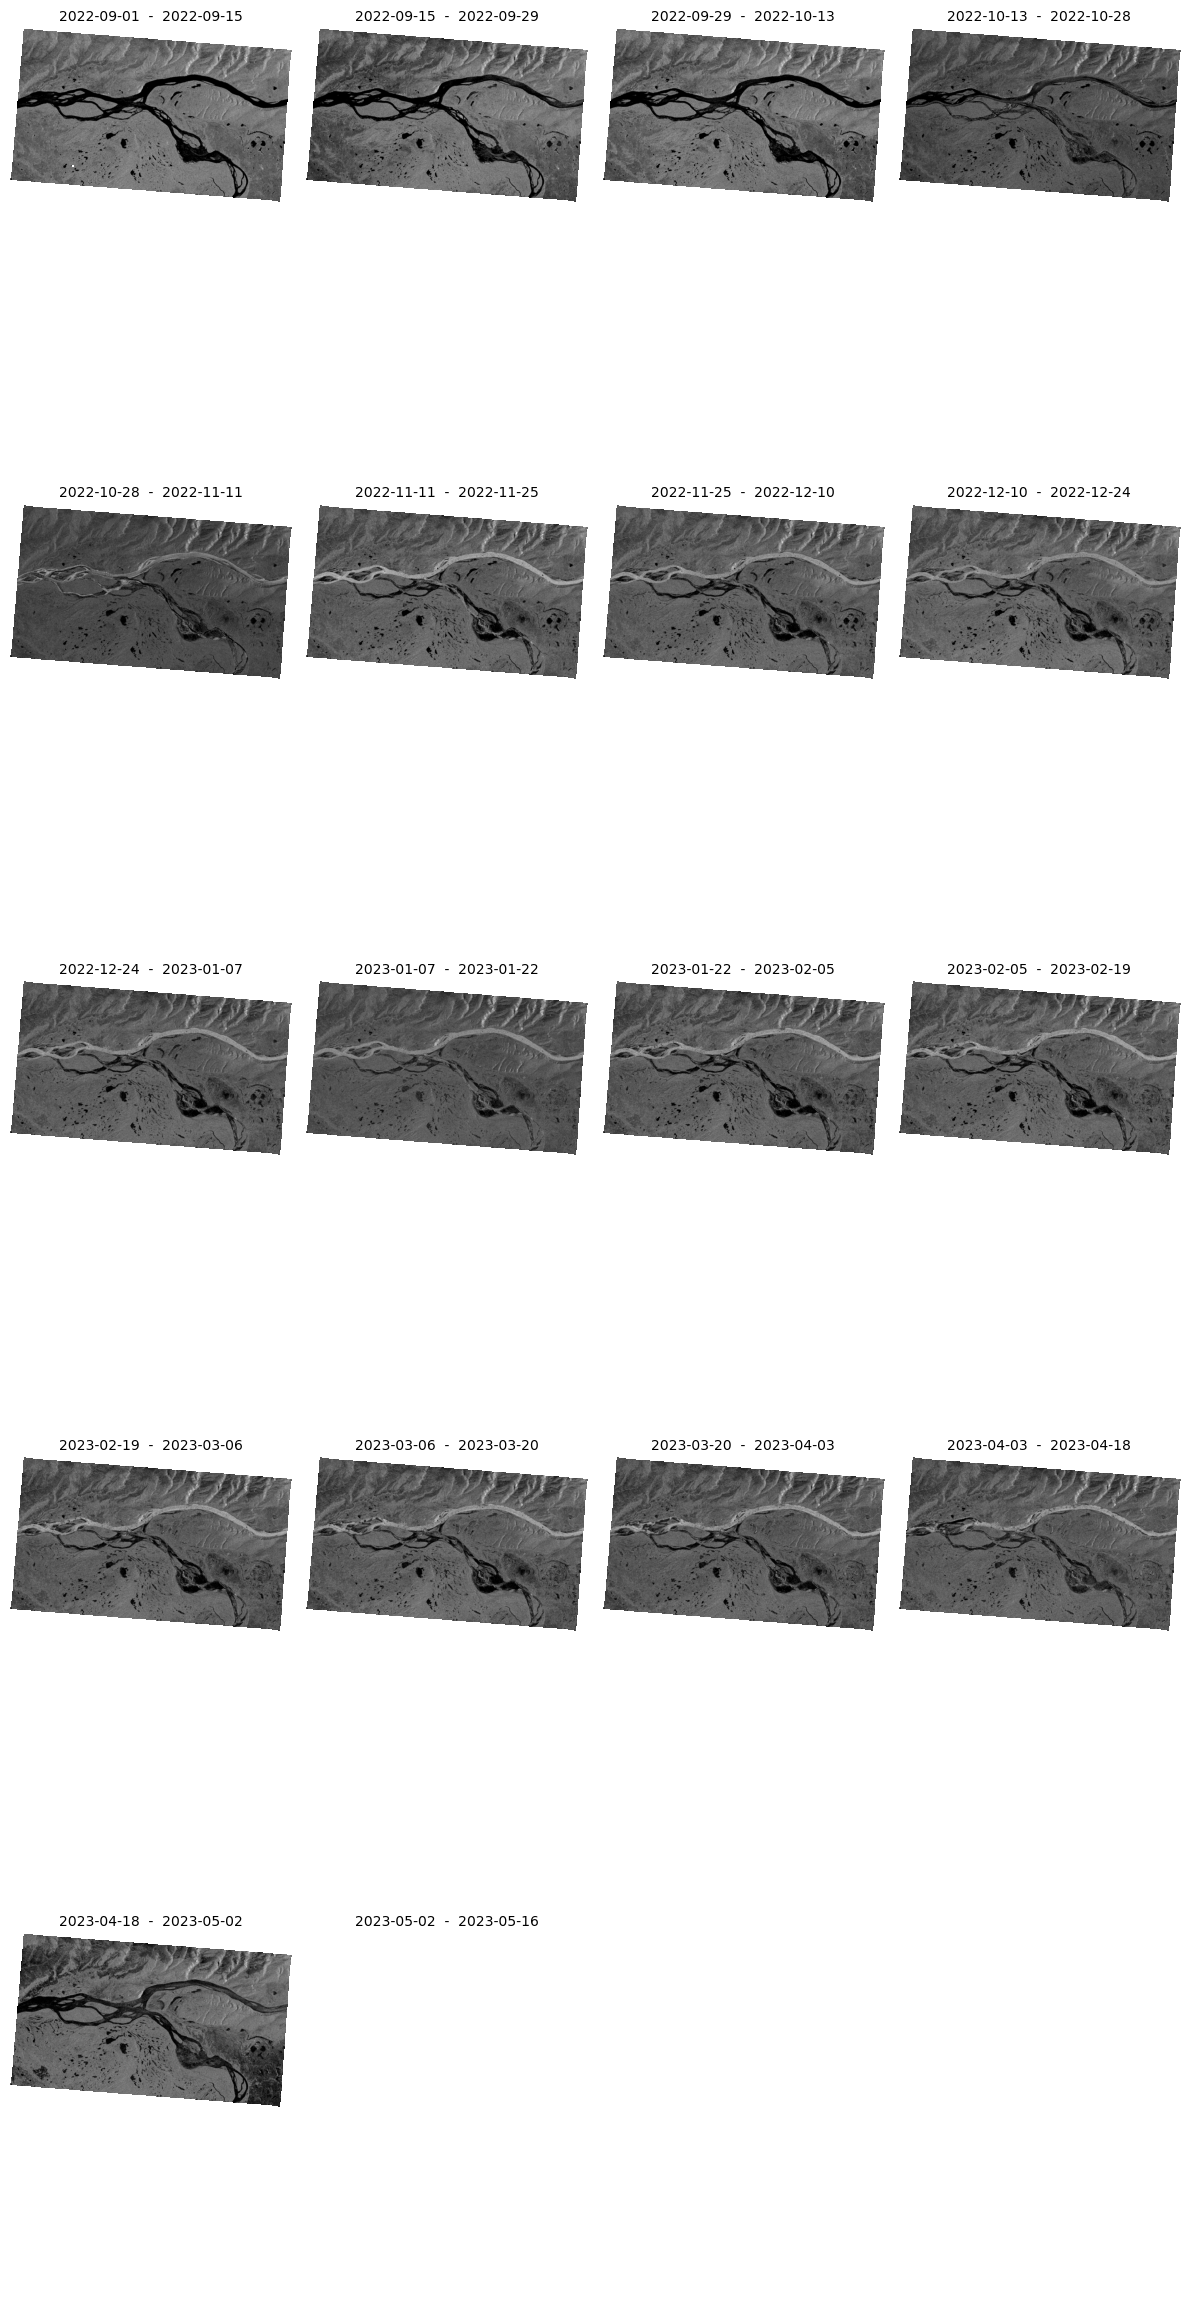

In [76]:
# Create a 4x4 grid of subplots to visualize the 16 bi-monthly SAR images.
ncols = 4
nrows = 5
aspect_ratio = 1.5
subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(2 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(data):
    ax = axs[idx // ncols][idx % ncols]
    ax.imshow(np.clip((image[:, :, 0]) * 3.5 / 255, 0, 1), cmap="gray")
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)

plt.tight_layout()
plt.show()

## Estimating a Threshold

 Ice pixels appear brighter (higher backscatter) compared to open water, because ice scatters electromagnetic waves in all directions, increasing the chance of detection by the sensor. Open water, by contrast, acts like a mirror and reflects most energy away from the sensor.

Based on SAR image interpretation of the slots with valid data, an initial threshold of 0.2 (on the normalised 0–1 dB scale, equivalent to 50/255) was evaluated but found to be unsuitable for this study area, as it failed to capture seasonal differences in ice coverage. A revised threshold of 0.35 was selected after visual comparison of summer and winter classifications, which better reflects the higher baseline backscatter of the surrounding boreal terrain along the Yukon River.

Note: Several time slots show no data due to limited Sentinel-1 acquisition frequency over the Yukon River basin. Unlike the original tutorial's study area (Nizhnesvirsky lower bay, Russia), the Yukon River has a sparser revisit schedule, with only 80 scenes available across the 9-month study period. Only slots with available acquisitions produce valid backscatter imagery.


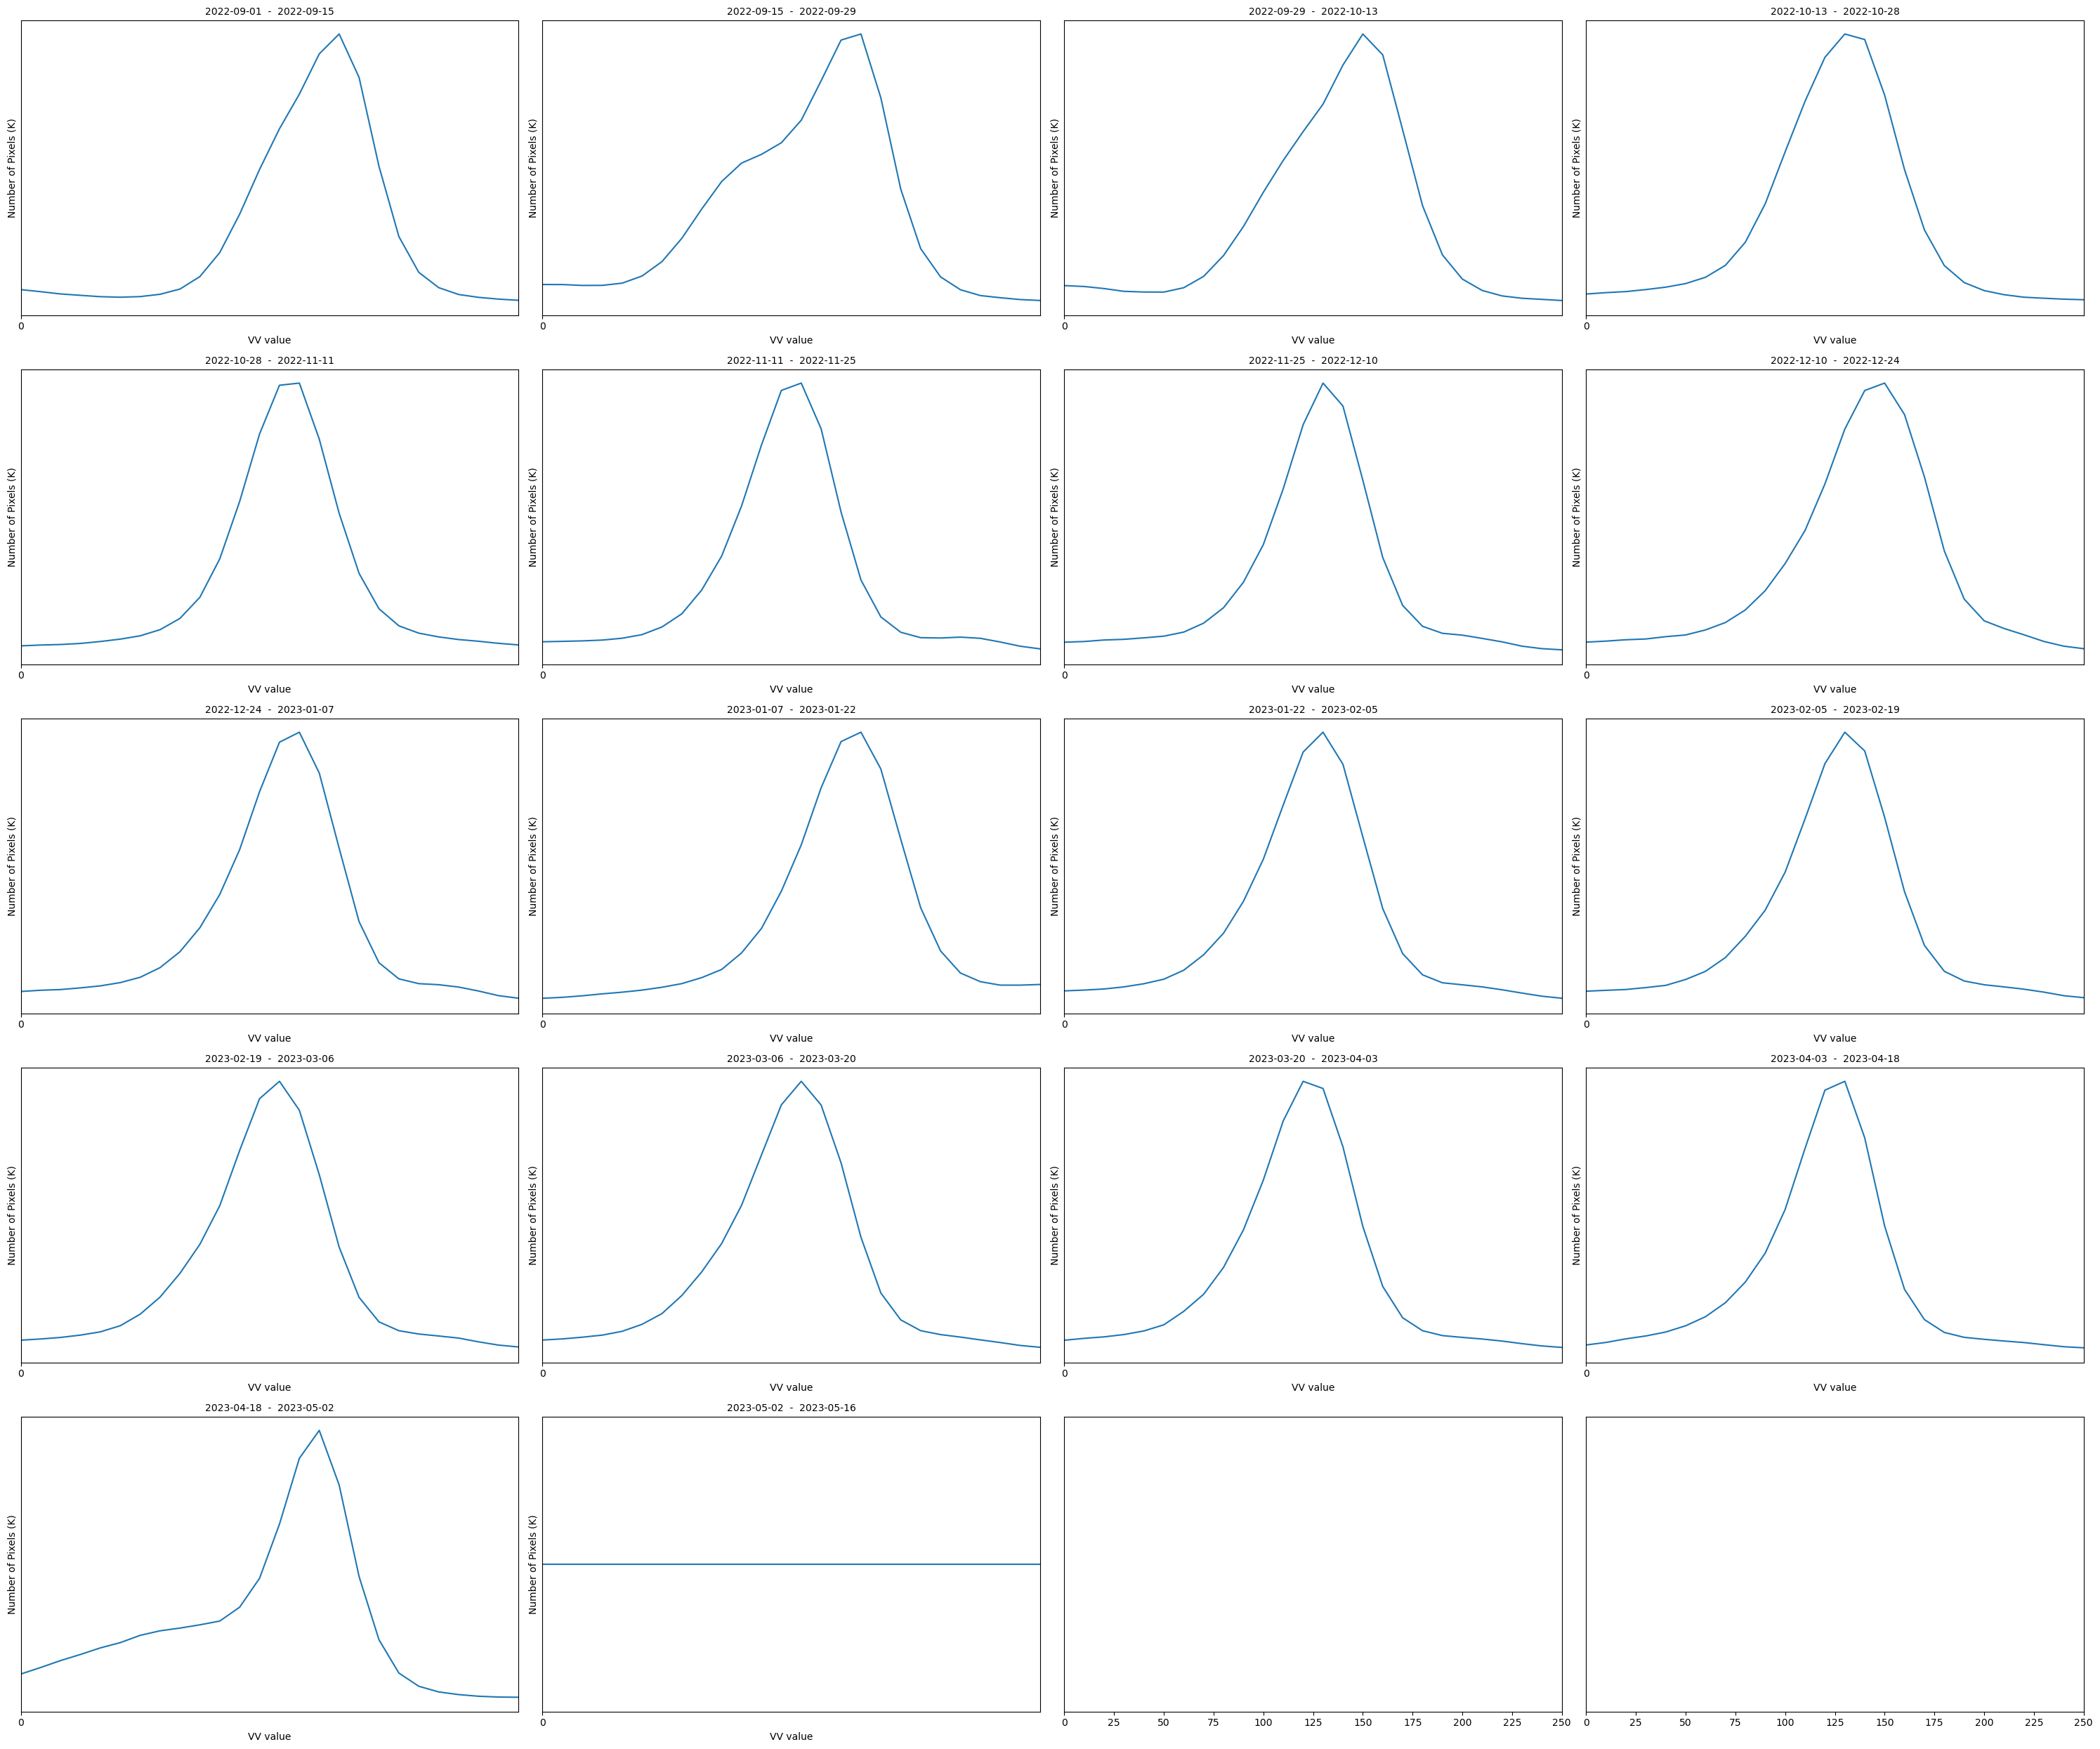

In [77]:
# Create a 4x4 grid of subplots to visualize the 16 bi-monthly SAR images.
ncols = 4
nrows = 5
aspect_ratio = 15 / 10
subplot_kw = {"xticks": range(0, 255, 25), "yticks": [], "frame_on": True}

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(data):
    histogram, bin_edges = np.histogram(
        image[:, :, 0][~np.isnan(image[:, :, 0])], bins=50, range=(0.0000001, 1)
    )
    ax = axs[idx // ncols][idx % ncols]
    ax.plot(bin_edges[0:-1], histogram)
    ax.set_xlabel("VV value")
    ax.set_ylabel("Number of Pixels (K)")
    ax.set_xlim((0, 0.5))
    # ax.set_ylim((0, 50000)) removed for better visualization of the histogram shape
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)

plt.tight_layout()
plt.show()

## Ice Mask Evalscript and Requests

The evalscript below classifies each pixel:
- **Blue** `[0, 0, 255]` → Open water (VV dB in [0, 0.2])
- **Cyan** `[0, 255, 255]` → Ice (VV dB in [0.35, 1])
- **Black** `[0, 0, 0]` → No data / land

Band 5 (`iceMask`) is `1` for ice pixels and `0` otherwise.

Note: The original threshold of 0.2 was recalibrated to 0.35 for this study area. Visual comparison of summer (September 2022) and winter (January 2023) classifications revealed that 0.2 produced near-identical results across seasons, failing to capture the freeze-thaw cycle, whereas 0.35 correctly showed open water conditions in summer and increased ice coverage in winter, reflecting the expected seasonal dynamics of the Yukon River.

In [93]:
evalscript_mask = """
  function setup() {
    return {
      input: ["VV", "dataMask"],
      output: { bands: 5, sampleType: "UINT8"}
    }
  }

function toDb(linear) {
  var log = 10 * Math.log(linear) / Math.LN10
  return Math.max(0, (log + 20) / 30)
}

function evaluatePixel(sample) {
  var VV = sample.VV;
  var iceMask = 0;
  VVdB = toDb(VV);
  if (VVdB > -0.001 && VVdB < 0.3) {
    iceMask = 0;
    return [0, 0, 255, sample.dataMask, iceMask]; // Water
  } else if (VVdB > 0.2 && VVdB < 1) {
    iceMask = 1;
    return [0, 255, 255, sample.dataMask, iceMask]; // Ice
  } else {
    iceMask = 0;
    return [0, 0, 0, sample.dataMask, iceMask]; // No data
  }
}
"""


def get_ice_mask_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_mask,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
                other_args={
                    "dataFilter": {
                        "resolution": "HIGH",
                        "mosaickingOrder": "mostRecent",
                    },
                    "processing": {
                        "backCoeff": "SIGMA0_ELLIPSOID",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 3,
                            "windowSizeY": 3,
                        },
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(river_gdf_metric.geometry.values[0], crs=river_gdf_metric.crs),
        resolution=[40, 40],
        config=config,
        data_folder="./results_mask",
    )

In [94]:
# Download ice mask data
list_of_requests = [get_ice_mask_request(slot) for slot in slots]
list_of_requests = [request.download_list[0] for request in list_of_requests]

mask_data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=5
)

## Visualise Ice / Water Classification Maps

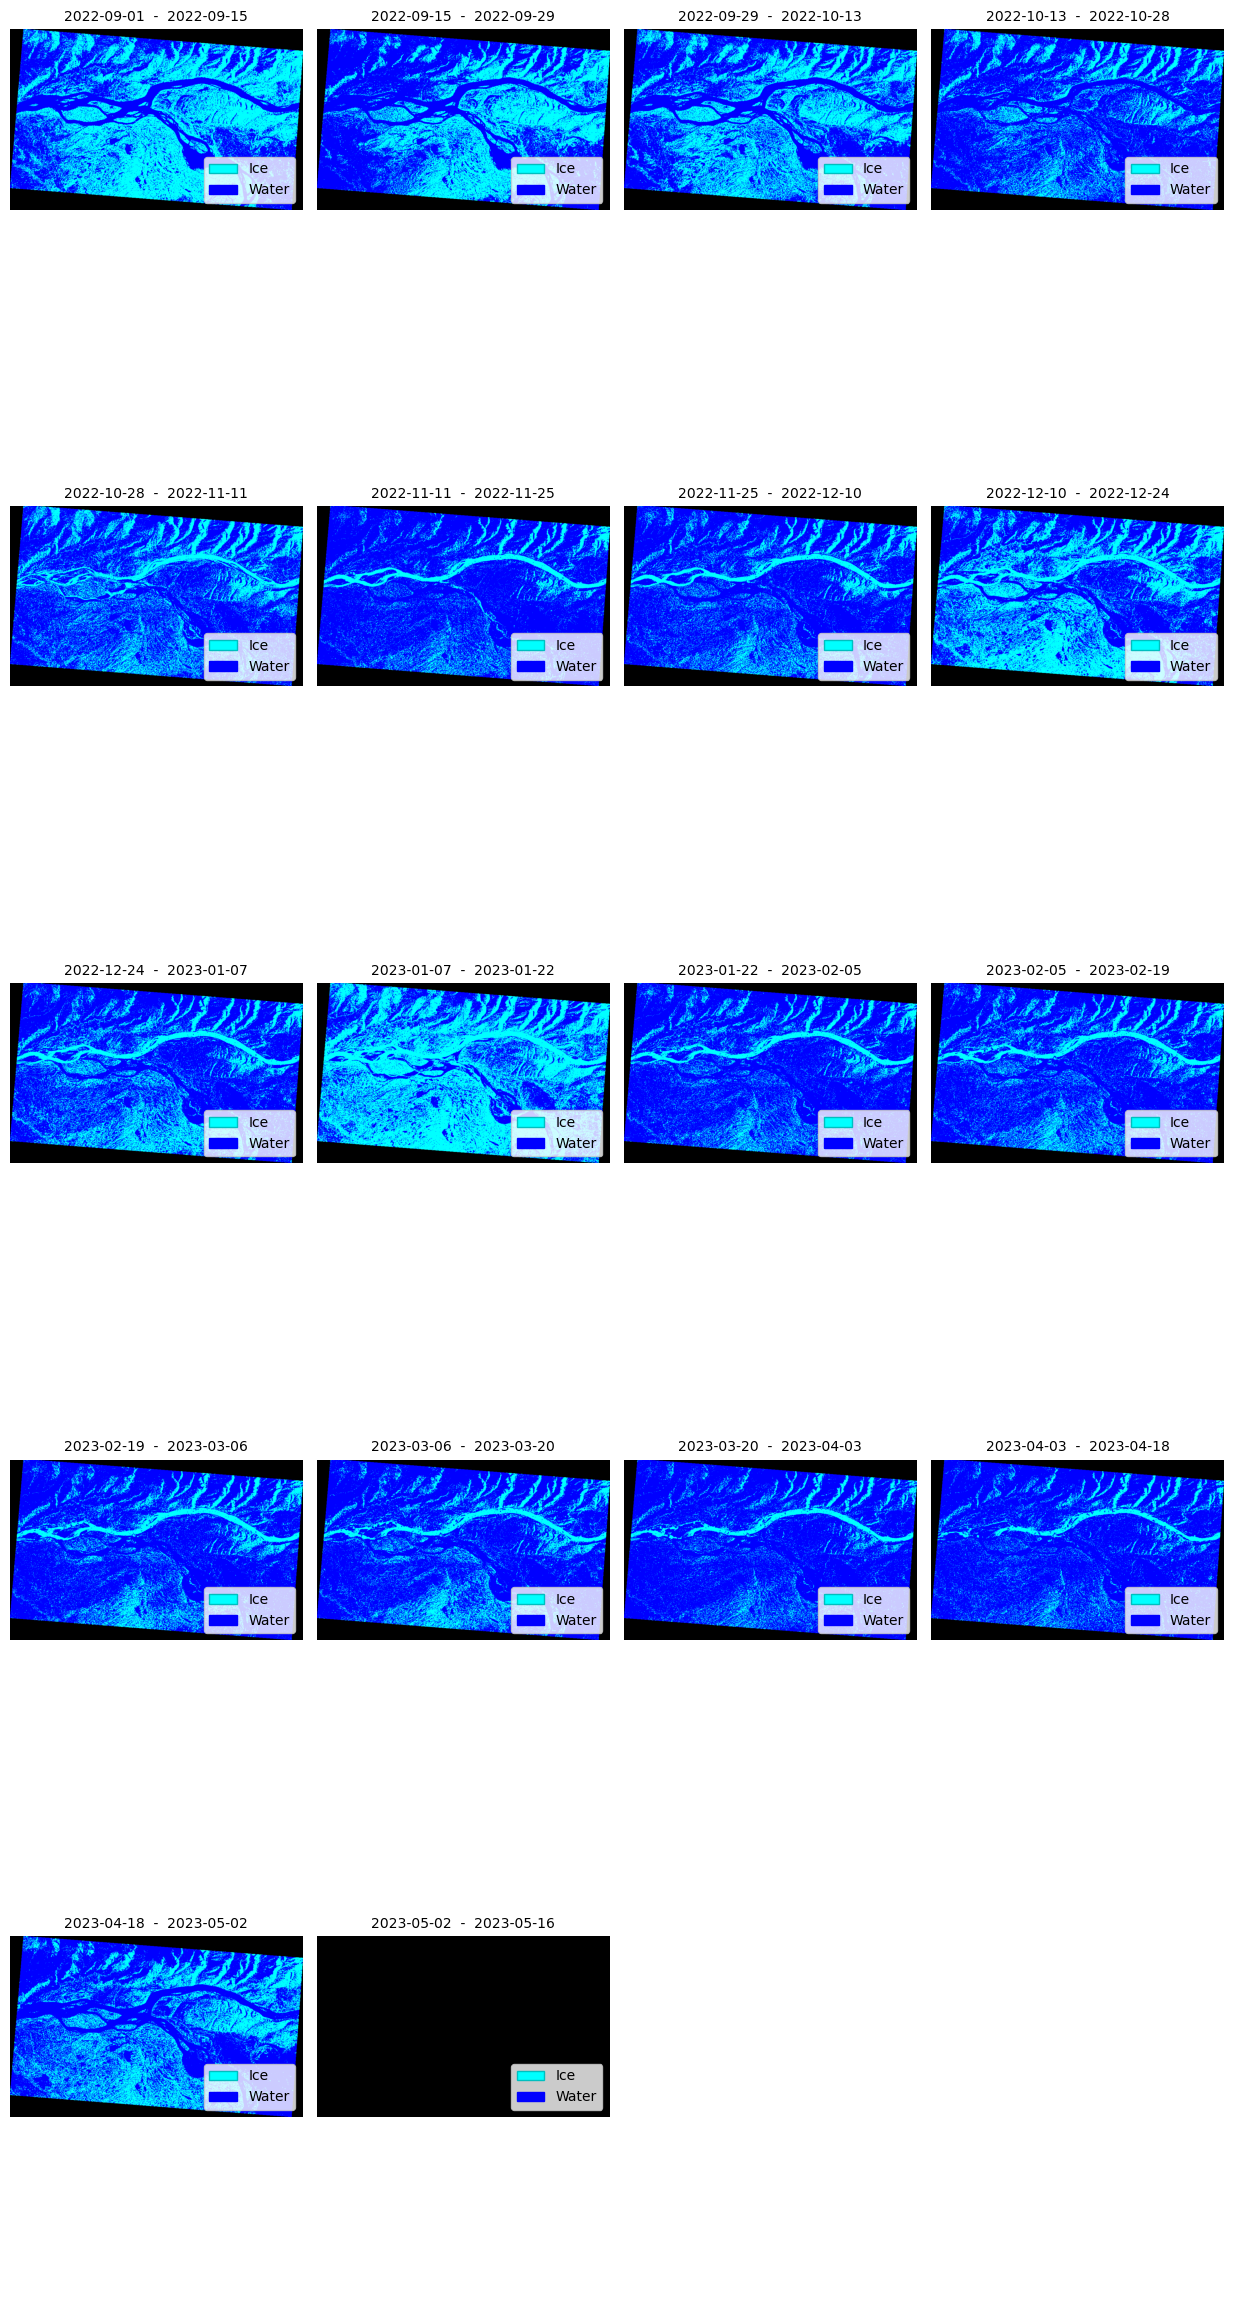

In [95]:
# Create a 4x4 grid of subplots to visualize the 16 bi-monthly SAR images with ice/water classification.
ncols = 4
nrows = 5
aspect_ratio = 1131 / 1819
subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}
legend_elements = [
    Patch(facecolor="cyan", edgecolor="c", label="Ice"),
    Patch(facecolor="blue", edgecolor="b", label="Water"),
]

fig, axs = plt.subplots(
    ncols=ncols,
    nrows=nrows,
    figsize=(5 * ncols * aspect_ratio, 5 * nrows),
    subplot_kw=subplot_kw,
)

for idx, image in enumerate(mask_data):
    ax = axs[idx // ncols][idx % ncols]
    ax.imshow(np.clip(image[:, :, :3], 0, 255))
    ax.set_title(f"{slots[idx][0]}  -  {slots[idx][1]}", fontsize=10)
    ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

## Creating a Time Series of Ice-Covered Area

Count ice pixels (band 5 == 1) and multiply by the pixel area (20 m × 20 m) to get area in km².

In [96]:
def count_ice_pixels(image):
    ice_mask = image[:, :, 4]
    return np.sum(ice_mask)

In [97]:
resolution_s1 = 20 * 20  # m² per pixel
area_covered_ice = []

for idx, image in enumerate(mask_data):
    ice_pixels_count = count_ice_pixels(image)
    area_covered_ice.append(ice_pixels_count * resolution_s1 / 1_000_000)  # km²

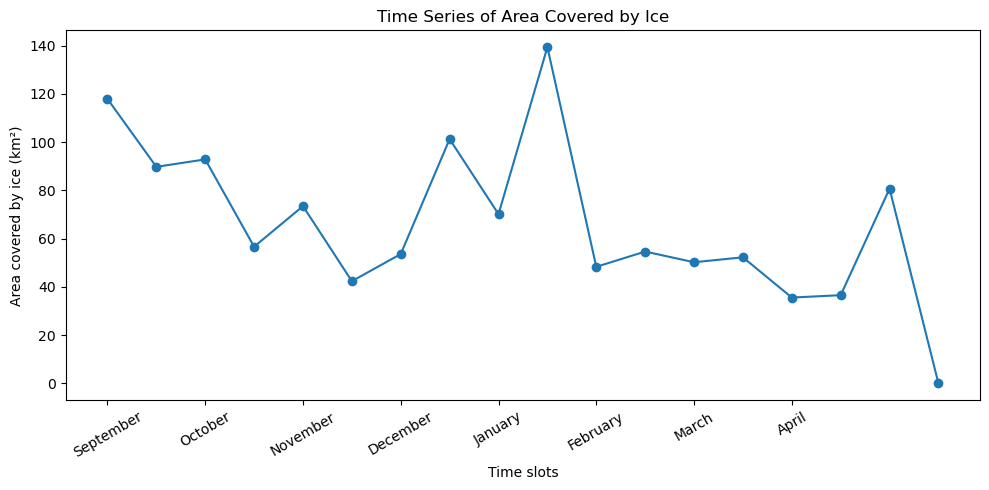

In [98]:
xlabels = [
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March",
    "April",
]

plt.figure(figsize=(10, 5))
plt.plot(range(len(slots)), area_covered_ice, marker="o")
plt.title("Time Series of Area Covered by Ice")
plt.xticks(np.arange(0, 16, step=2), xlabels, rotation=30, ha="center")
plt.xlabel("Time slots")
plt.ylabel("Area covered by ice (km²)")
plt.tight_layout()
plt.show()

## Summary

- Ice formation in this section of the Tanana section of the Yukon River began in **late October 2022** and peaked through the winter months.
- Once ice breakup began in **late April 2023**, the river cleared rapidly.
- The classification used a VV dB threshold of **0.2** to separate open water (low backscatter) from ice (high backscatter).
- Sentinel-1 SAR data is well-suited for this task as it is unaffected by cloud cover or daylight conditions.